In [15]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt 
import numpy as np

In [16]:
# load datasets 
(X_train, y_train), (X_test, y_test)= datasets.cifar10.load_data()

In [17]:
X_test.shape

(10000, 32, 32, 3)

In [18]:
X_train.shape

(50000, 32, 32, 3)

In [19]:
y_train= y_train.reshape(-1,)
# -1 means single column conversion

In [20]:
y_test=y_test.reshape(-1,)

In [21]:
classes=['airplane','automobile','cat','bird','dear','dog','frog','horse','ship','truck']

In [22]:
def plot_sample(X,y,index):
    plt.figure(figsize=(5,2))
    plt.imshow(X[index])
    plt.xlabel(classes[y[index]])
    

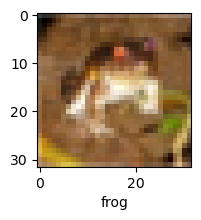

In [27]:
plot_sample(X_train,y_train,0)

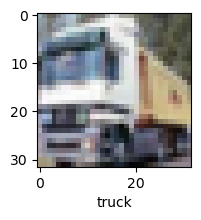

In [28]:
plot_sample(X_train,y_train,1)

In [29]:
# NORMALIZATION 

X_train=X_train/255.0
X_test=X_test/255.0

In [30]:
#@ ANN Model, compile fit
ann= models.Sequential([
    layers.Flatten(input_shape= (32,32,3)), 
    layers.Dense(3000, activation= 'relu'),
    layers.Dense(1000,activation= 'relu'),
    layers.Dense(10, activation= 'softmax')
                 ])

ann.compile(optimizer='SGD', loss= 'sparse_categorical_crossentropy',metrics=['accuracy'])
ann.fit(X_train,y_train,epochs=5)

C:\Users\hp\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 69s 44ms/step - accuracy: 0.3546 - loss: 1.8173
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 69s 44ms/step - accuracy: 0.4248 - loss: 1.6262
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 73s 47ms/step - accuracy: 0.4559 - loss: 1.5441
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 80s 51ms/step - accuracy: 0.4765 - loss: 1.4839
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 90s 57ms/step - accuracy: 0.4967 - loss: 1.4341


In [32]:
# CNN MODEL
cnn= models.Sequential([
    layers.Conv2D(filters= 32, kernel_size=(3,3),activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),
    
    layers.Conv2D(filters= 32, kernel_size=(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64,activation='relu'),
    layers.Dense(10,activation='softmax')
])

C:\Users\hp\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [33]:
# CNN COMPILE 
cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics= ['accuracy'])
cnn.fit(X_train,y_train,epochs=10)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - accuracy: 0.4447 - loss: 1.5348
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.5844 - loss: 1.1800
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.6292 - loss: 1.0591
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.6556 - loss: 0.9876
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 29s 18ms/step - accuracy: 0.6734 - loss: 0.9318
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 32s 21ms/step - accuracy: 0.6930 - loss: 0.8860
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 37s 24ms/step - accuracy: 0.7041 - loss: 0.8509
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 25s 16ms/step - accuracy: 0.7184 - loss: 0.8116
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 43s 27ms/step - accuracy: 0.7261 - loss: 0.7837
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.7366 - loss: 0.7536


In [34]:
# CNN EVALAUTE 
cnn.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6954 - loss: 0.9117


[0.9117087125778198, 0.6953999996185303]

In [36]:
# predict midel
y_pred=cnn.predict(X_test)
y_pred[:5]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


array([[8.5732533e-04, 2.0763226e-05, 6.1063301e-02, 6.7828685e-01,
        2.9580793e-03, 1.6045830e-01, 9.4335437e-02, 6.9230259e-04,
        1.2729976e-03, 5.4672942e-05],
       [1.6924503e-03, 2.0002393e-01, 3.7709181e-06, 1.8704429e-06,
        1.5595192e-07, 2.3044862e-07, 8.2399218e-08, 1.6612971e-07,
        7.9483068e-01, 3.4465976e-03],
       [1.2351504e-01, 1.9353469e-01, 3.7043004e-03, 1.2537654e-02,
        3.8659391e-03, 2.2490995e-03, 1.5351686e-04, 3.4159347e-03,
        6.3751876e-01, 1.9505022e-02],
       [7.8939813e-01, 6.7893341e-02, 2.1507099e-02, 6.2081262e-02,
        7.2544701e-03, 2.5900661e-03, 5.1761693e-03, 1.3157468e-03,
        4.1036293e-02, 1.7473971e-03],
       [7.8631672e-07, 1.3704231e-06, 1.1426938e-02, 6.5592867e-03,
        6.3508004e-01, 5.4628663e-03, 3.4142625e-01, 3.7494134e-05,
        3.9878946e-06, 1.0268029e-06]], dtype=float32)

In [37]:
# Lavel prediction
y_classes=[np.argmax(element) for element in y_pred]
y_classes[:5]


[np.int64(3), np.int64(8), np.int64(8), np.int64(0), np.int64(4)]

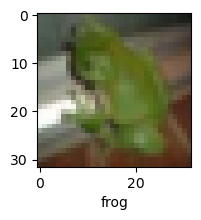

In [47]:
plot_sample(X_test, y_test,7)

In [46]:
classes[y_classes[7]]

'cat'